In [1]:
# Import aller Bibliotheken
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import accuracy_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras import preprocessing
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from tensorflow.keras.losses import mse, binary_crossentropy
print(tf.__version__)

2.17.0


In [2]:
# Trainings- und Validierungsdatensatz laden
m14x14 = pd.read_csv('class_128_400_14x14.csv')
m14x14.head(6)

,label,p0,p1,p2,p3,p4,p5,p6,p7,p8,...,p186,p187,p188,p189,p190,p191,p192,p193,p194,p195
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
# Datensatz aufbereiten: Skalieren auf Wertebereich zwischen 0 und 1 UND Splitten in Train und Test.
feature_spalten = []
for i in range(0, 196): 
    feature_spalten.append("p"+str(i))

X = m14x14[feature_spalten]
scaler = MinMaxScaler()
X = scaler.fit_transform(X)
y = m14x14['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42) # 70% training and 30% test

In [4]:
# Dimensionen des Inputs
input_dim = X_train.shape[1]

# Dimensionen des latenten Raums
latent_dim = 2

# Encoder
inputs = layers.Input(shape=(input_dim,)) # 14x14 Pixel
h = layers.Dense(128, activation='relu')(inputs)
h = layers.Dense(64, activation='relu')(h)
h = layers.Dense(32, activation='relu')(h)
h = layers.BatchNormalization()(h)

# Latente Variable: Mean und Log-Varianz (sigma)
z_mean = layers.Dense(latent_dim, name='z_mean')(h)
z_log_var = layers.Dense(latent_dim, name='z_log_var')(h)


In [5]:
# KL-Divergenz-Verlust innerhalb eines Layers
class KLDivergenceLayer(tf.keras.layers.Layer):
    def call(self, z_mean, z_log_var):
        kl_loss = -0.5 * tf.reduce_mean(
            1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
        )
        self.add_loss(kl_loss)  # Verlust direkt zur Schicht hinzufügen
        return z_mean  # Gib z_mean zurück, um es im Decoder zu verwenden

# Füge den KLDivergenceLayer zum Modell hinzu
z = KLDivergenceLayer()(z_mean, z_log_var)

In [6]:
# Decoder
decoder_h1 = layers.Dense(32, activation='relu')
decoder_h2 = layers.Dense(64, activation='relu')
decoder_h3 = layers.Dense(128, activation='relu')
decoder_mean = layers.Dense(input_dim, activation='sigmoid') # Rekonstruierte Bilder

h_decoded = decoder_h1(z)
h_decoded = decoder_h2(h_decoded)
h_decoded = decoder_h3(h_decoded)
outputs = decoder_mean(h_decoded)

decoder = Model(z, outputs, name='decoder')

In [7]:
class ReconstructionLossLayer(tf.keras.layers.Layer):
    def call(self, inputs, outputs):
        reconstruction_loss = tf.reduce_sum(tf.square(outputs - inputs))
        self.add_loss(reconstruction_loss)
        return outputs  # Gib outputs zurück, um es weiterzugeben

outputs = ReconstructionLossLayer()(inputs, outputs)

In [8]:
vae = Model(inputs, outputs)

vae.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 196)               │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 128)               │          25,216 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 64)                │           8,256 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 32)                │           2,080 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 32)                │             128 │ dense_2[0][0]              │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ z_mean (Dense)                │ (None, 2)                 │              66 │ batch_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ z_log_var (Dense)             │ (None, 2)                 │              66 │ batch_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ kl_divergence_layer           │ (None, 2)                 │               0 │ z_mean[0][0],              │
│ (KLDivergenceLayer)           │                           │                 │ z_log_var[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 32)                │              96 │ kl_divergence_layer[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_4 (Dense)               │ (None, 64)                │           2,112 │ dense_3[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_5 (Dense)               │ (None, 128)               │           8,320 │ dense_4[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_6 (Dense)               │ (None, 196)               │          25,284 │ dense_5[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ reconstruction_loss_layer     │ (None, 196)               │               0 │ input_layer[0][0],         │
│ (ReconstructionLossLayer)     │                           │                 │ dense_6[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 71,624 (279.78 KB)

 Trainable params: 71,560 (279.53 KB)

 Non-trainable params: 64 (256.00 B)

In [9]:
vae.compile(optimizer='adam')

In [10]:
# Training
history = vae.fit(X_train, X_train, epochs=100, batch_size=12, validation_data=(X_test, X_test))


Epoch 1/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - loss: 370.7575 - val_loss: 141.5807
Epoch 2/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 124.0547 - val_loss: 117.6487
Epoch 3/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 111.9334 - val_loss: 108.3893
Epoch 4/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 111.7197 - val_loss: 103.3895
Epoch 5/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 109.2411 - val_loss: 100.6354
Epoch 6/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 104.3067 - val_loss: 98.1920
Epoch 7/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 104.4483 - val_loss: 97.2176
Epoch 8/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 102.5814 - val_loss: 96.1964
Epoch 9/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 101.3704 - val_loss: 93.7550
Epoch 10/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 101.0446 - val_loss: 92.8766
Epoch 11/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 97.8744 - val_loss: 91.9534
Epoch 12/100
70/70 ━━━━

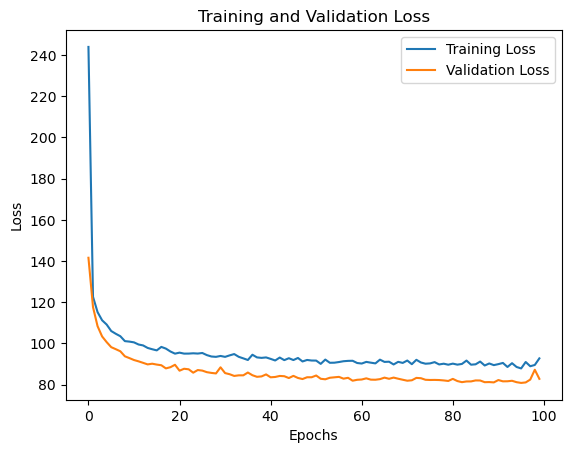

In [11]:
# Plotten des Trainings- und Validierungsverlusts
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


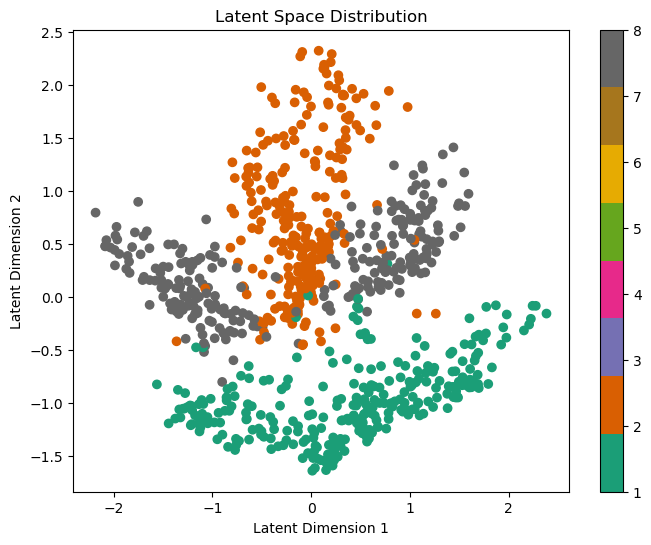

In [12]:
# Encoder-Modell definieren, um den latenten Raum zu projizieren
encoder = Model(inputs, z_mean)  # Hier verwenden wir z_mean, um die latente Verteilung zu visualisieren

# Projektion der Daten in den latenten Raum
z_train = encoder.predict(X_train)

# Plotten des latenten Raumes
plt.figure(figsize=(8, 6))
plt.scatter(z_train[:, 0], z_train[:, 1], c=y_train, cmap='Dark2')
plt.colorbar()
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.title('Latent Space Distribution')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 493ms/step


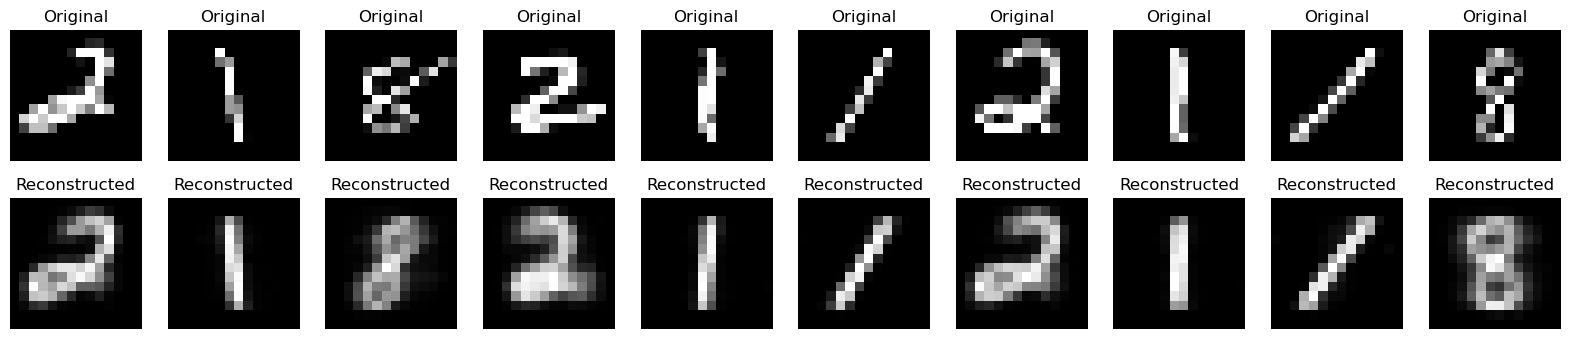

In [13]:
# Einige Testbilder auswählen
num_samples = 10
random_indices = np.random.choice(X_test.shape[0], num_samples)

# Rekonstruktion der ausgewählten Bilder
reconstructions = vae.predict(X_test[random_indices])

# Originalbilder und rekonstruktionen plotten
plt.figure(figsize=(20, 4))
for i in range(num_samples):
    # Originalbild
    ax = plt.subplot(2, num_samples, i + 1)
    plt.imshow(X_test[random_indices[i]].reshape(14, 14), cmap='gray')
    plt.title("Original")
    plt.axis('off')
    
    # Rekonstruiertes Bild
    ax = plt.subplot(2, num_samples, i + 1 + num_samples)
    plt.imshow(reconstructions[i].reshape(14, 14), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step


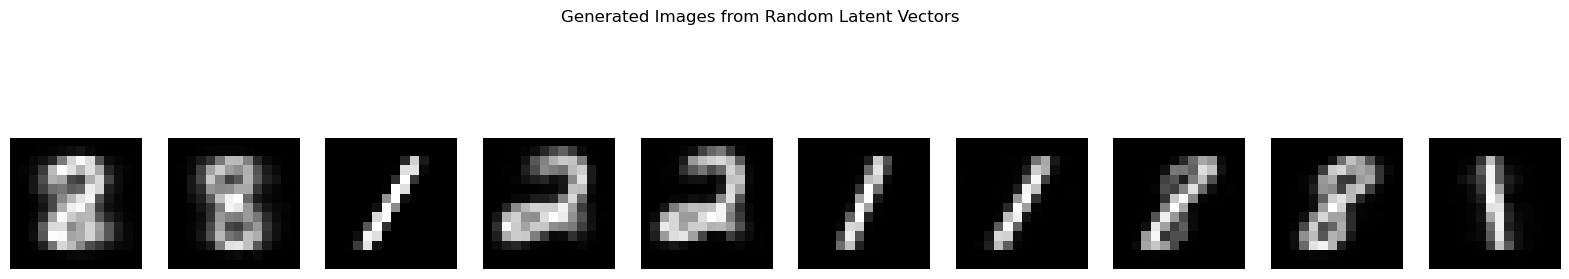

In [14]:
# Zufällige Punkte im latenten Raum generieren
n = 10  # Anzahl der zu generierenden Bilder
random_latent_vectors = np.random.normal(size=(n, latent_dim))

# Durch den Decoder gehen, um neue Bilder zu generieren
generated_images = decoder.predict(random_latent_vectors)

# Generierte Bilder plotten
plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(1, n, i + 1)
    plt.imshow(generated_images[i].reshape(14, 14), cmap='gray')
    plt.axis('off')

plt.suptitle('Generated Images from Random Latent Vectors')
plt.show()

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


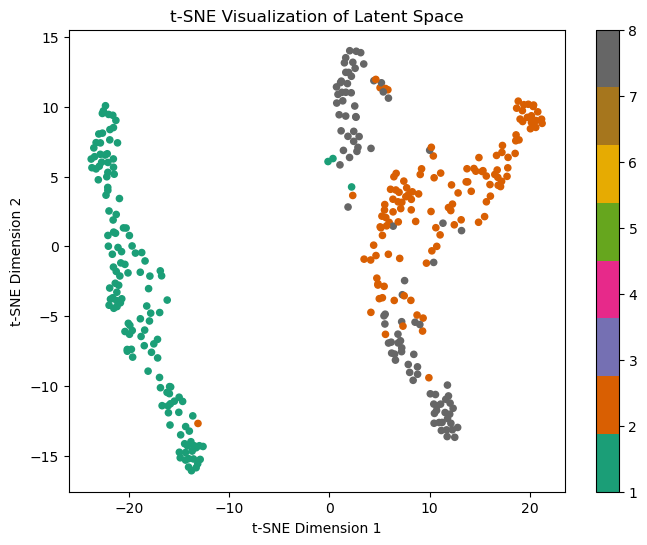

In [15]:
# 1. Importieren Sie die notwendigen Bibliotheken
from sklearn.manifold import TSNE

# 2. Extrahieren der latenten Variablen mit dem Encoder-Modell
z_mean = encoder.predict(X_test)

# 3. Anwenden von t-SNE auf die latenten Variablen
tsne = TSNE(n_components=2, random_state=42)
z_tsne = tsne.fit_transform(z_mean)

# 4. Visualisieren der t-SNE-Transformation
plt.figure(figsize=(8, 6))
plt.scatter(z_tsne[:, 0], z_tsne[:, 1], c=y_test, cmap='Dark2', s=20)
plt.colorbar()
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.title('t-SNE Visualization of Latent Space')
plt.show()